In [84]:
EXCLUDED_TEST_IDS = {} #{f"test_id_{i}" for i in range(16, 21)} | {f"test_id_{i}" for i in range(26, 31)}

In [85]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _filter_results_by_test_id(results: dict):
    return {k: v for k, v in results.items() if k not in EXCLUDED_TEST_IDS}


def _resolve_eval_json(target_rel: str | Path):
    target_rel = Path(target_rel)

    # Support both full relative paths and bare filenames.
    search_candidates = [target_rel]
    if not target_rel.is_absolute() and target_rel.parent == Path("."):
        search_candidates.extend(
            [
                Path("data/llm_eval_results_compare/comparison_llm_eval_results") / target_rel,
                Path("data/comparison_llm_eval_results") / target_rel,
            ]
        )

    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in search_candidates:
            candidate = base / rel
            if candidate.exists():
                resolved = candidate
                break
        if resolved is not None:
            break

    if resolved is None:
        attempted = ", ".join(str(p) for p in search_candidates)
        raise FileNotFoundError(
            f"Cannot find any of [{attempted}]. Current working directory: {Path.cwd()}"
        )

    with resolved.open("r", encoding="utf-8") as f:
        return resolved, json.load(f)


def plot_eval_results(
    target_rel: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results/self_generated_test_cases_eval.json",
    runs_per_query: int = 5,
):
    resolved, data = _resolve_eval_json(target_rel)

    results = _filter_results_by_test_id(data["results"])
    sorted_keys = sorted(results.keys(), key=lambda x: int(x.split("_")[-1]))

    metric_series = {
        "policy_faithfulness": np.array(
            [results[k].get("policy", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_answer_relevance": np.array(
            [results[k].get("policy", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_correctness": np.array(
            [results[k].get("policy", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_faithfulness": np.array(
            [results[k].get("provider", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_answer_relevance": np.array(
            [results[k].get("provider", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_correctness": np.array(
            [results[k].get("provider", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "query_alignment": np.array(
            [results[k].get("query_alignment", {}).get("comparison_query_relevance", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "correctness": np.array(
            [results[k].get("compare_quality", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_sim": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_sim", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_diff": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_diff", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "completeness": np.array(
            [results[k].get("compare_quality", {}).get("completeness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "balance": np.array(
            [results[k].get("compare_quality", {}).get("balance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "comparison_overall_score": np.array(
            [results[k].get("comparison_overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "overall_score": np.array(
            [results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
    }

    plot_metrics = [
        "policy_faithfulness",
        "policy_answer_relevance",
        "policy_correctness",
        "provider_faithfulness",
        "provider_answer_relevance",
        "provider_correctness",
        "query_alignment",
        "correctness",
        "accuracy_sim",
        "accuracy_diff",
        "completeness",
        "balance",
        "comparison_overall_score",
        "overall_score",
    ]

    print(f"Loaded from: {resolved}")
    print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
    print(f"Total cases after filter: {len(sorted_keys)}")
    print(f"Runs per query: {runs_per_query}")

    fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(9, 4 * len(plot_metrics)), sharex=False)
    if len(plot_metrics) == 1:
        axes = [axes]

    for ax, metric_name in zip(axes, plot_metrics):
        values = np.asarray(metric_series[metric_name], dtype=float)
        usable = values[: (len(values) // runs_per_query) * runs_per_query]
        grouped = usable.reshape(-1, runs_per_query)

        means = grouped.mean(axis=1)
        stds = grouped.std(axis=1)
        x = np.arange(len(means))

        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='black', label='Mean ± Std', zorder=3)

        for i in range(grouped.shape[0]):
            jitter = np.random.normal(i, 0.05, size=grouped.shape[1])
            if i == 0:
                ax.scatter(jitter, grouped[i], alpha=0.6, label='Individual Runs', zorder=2)
            else:
                ax.scatter(jitter, grouped[i], alpha=0.6, zorder=2)

        ax.set_xlabel("Query ID")
        ax.set_ylabel("Score")
        ax.set_title(f"{metric_name} Stability and Distribution Across {runs_per_query} Runs")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{i+1}" for i in range(len(means))])
        ax.legend()
        ax.grid(True, axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()
    return resolved, metric_series


# Aggregated Visualization

## All Files

Loaded 12 files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse] gemini: n=60, mean=0.815
  [dense_sparse] gpt5.4mini: n=60, mean=0.819
  [dense_sparse_p2p] gemini: n=60, mean=0.829
  [dense_sparse_p2p] gpt5.4mini: n=60, mean=0.801
  [llm_extract] gemini: n=60, mean=0.760
  [llm_extract] gpt5.4mini: n=60, mean=0.792
  [llm_extract_p2p] gemini: n=60, mean=0.802
  [llm_extract_p2p] gpt5.4mini: n=60, mean=0.782
  [theme_aware] gemini: n=60, mean=0.808
  [theme_aware] gpt5.4mini: n=60, mean=0.803
  [theme_aware_p2p] gemini: n=60, mean=0.807
  [theme_aware_p2p] gpt5.4mini: n=60, mean=0.774


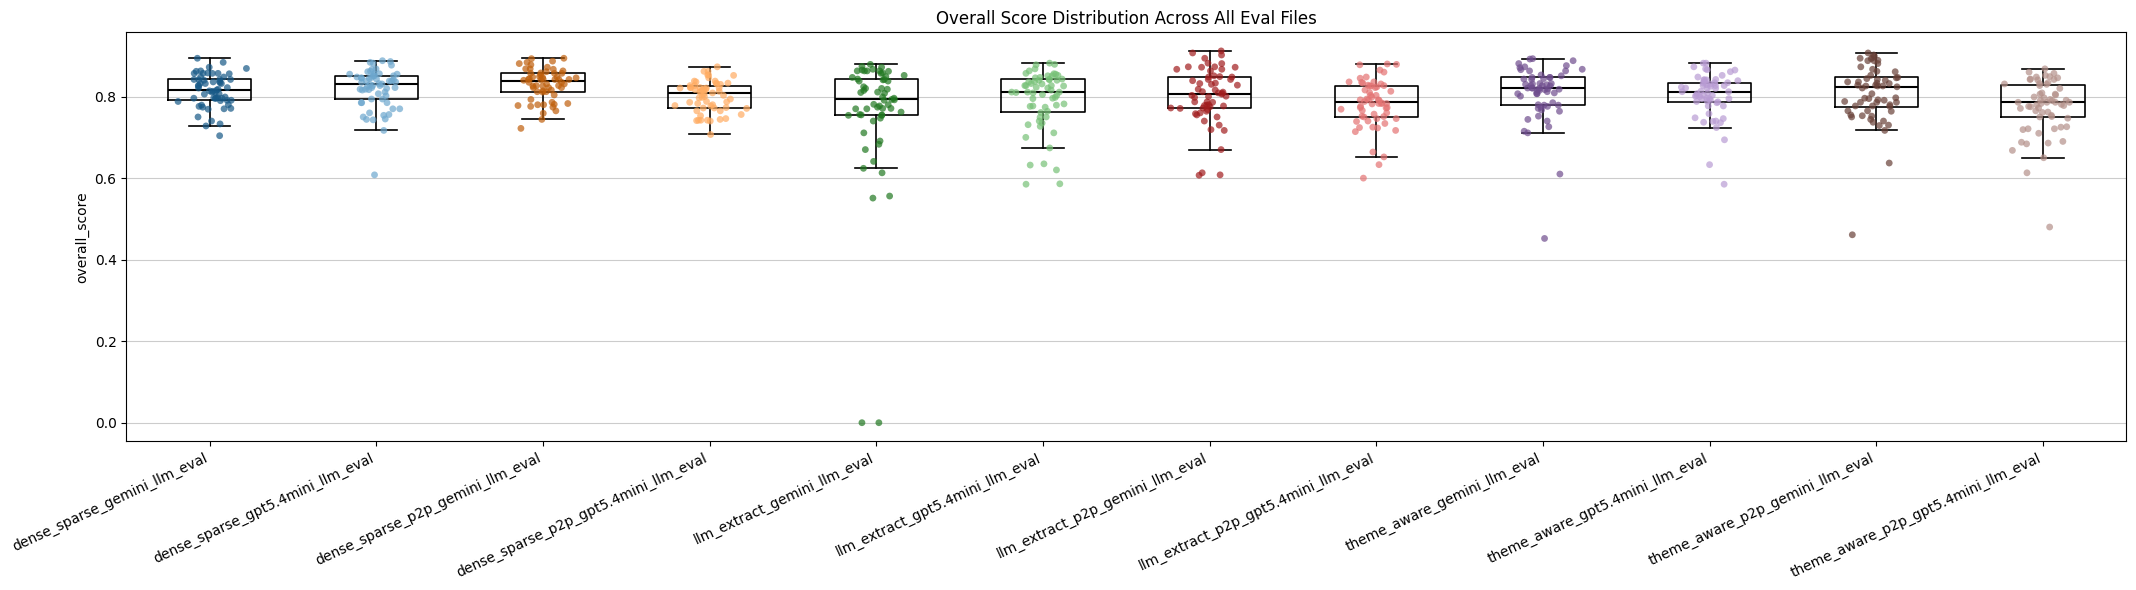

In [86]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors


def _resolve_eval_dir(target_dir: str | Path):
    target_dir = Path(target_dir)
    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / target_dir
        if candidate.exists():
            resolved = candidate
            break

    if resolved is None:
        raise FileNotFoundError(
            f"Cannot find {target_dir}. Current working directory: {Path.cwd()}"
        )

    return resolved


def _group_model_sort_key(stem: str):
    suffix = "_llm_eval"
    core = stem[:-len(suffix)] if stem.endswith(suffix) else stem

    # Match known model suffixes at the end so group names can contain any underscores.
    known_models = ["gemini", "gpt5.4mini"]
    for model_name in known_models:
        marker = f"_{model_name}"
        if core.endswith(marker):
            group_name = core[: -len(marker)]
            return group_name, model_name

    # Fallback for unexpected names: keep deterministic ordering.
    return core, ""


def _group_name_from_stem(stem: str):
    group_name, _ = _group_model_sort_key(stem)
    return group_name


def _build_group_color_map(stems):
    group_order = []
    for stem in stems:
        group_name = _group_name_from_stem(stem)
        if group_name not in group_order:
            group_order.append(group_name)

    cmap = plt.get_cmap("tab10")
    return {group: cmap(i % 10) for i, group in enumerate(group_order)}


def _blend_with_white(color, amount=0.35):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1.0 - rgb) * amount)


def _blend_with_black(color, amount=0.25):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb * (1.0 - amount))


def _model_tinted_color(label: str, group_color_map):
    group_name, model_name = _group_model_sort_key(label)
    base_color = group_color_map[group_name]

    model = str(model_name).lower()
    if model == "gemini":
        return _blend_with_black(base_color, amount=0.25)
    if "gpt" in model:
        return _blend_with_white(base_color, amount=0.35)
    return base_color


def plot_all_files_overall_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        list(resolved_dir.glob(pattern)),
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("Overall Score Distribution Across All Eval Files", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


file_scores = plot_all_files_overall_scores()

### Zoomed Graph

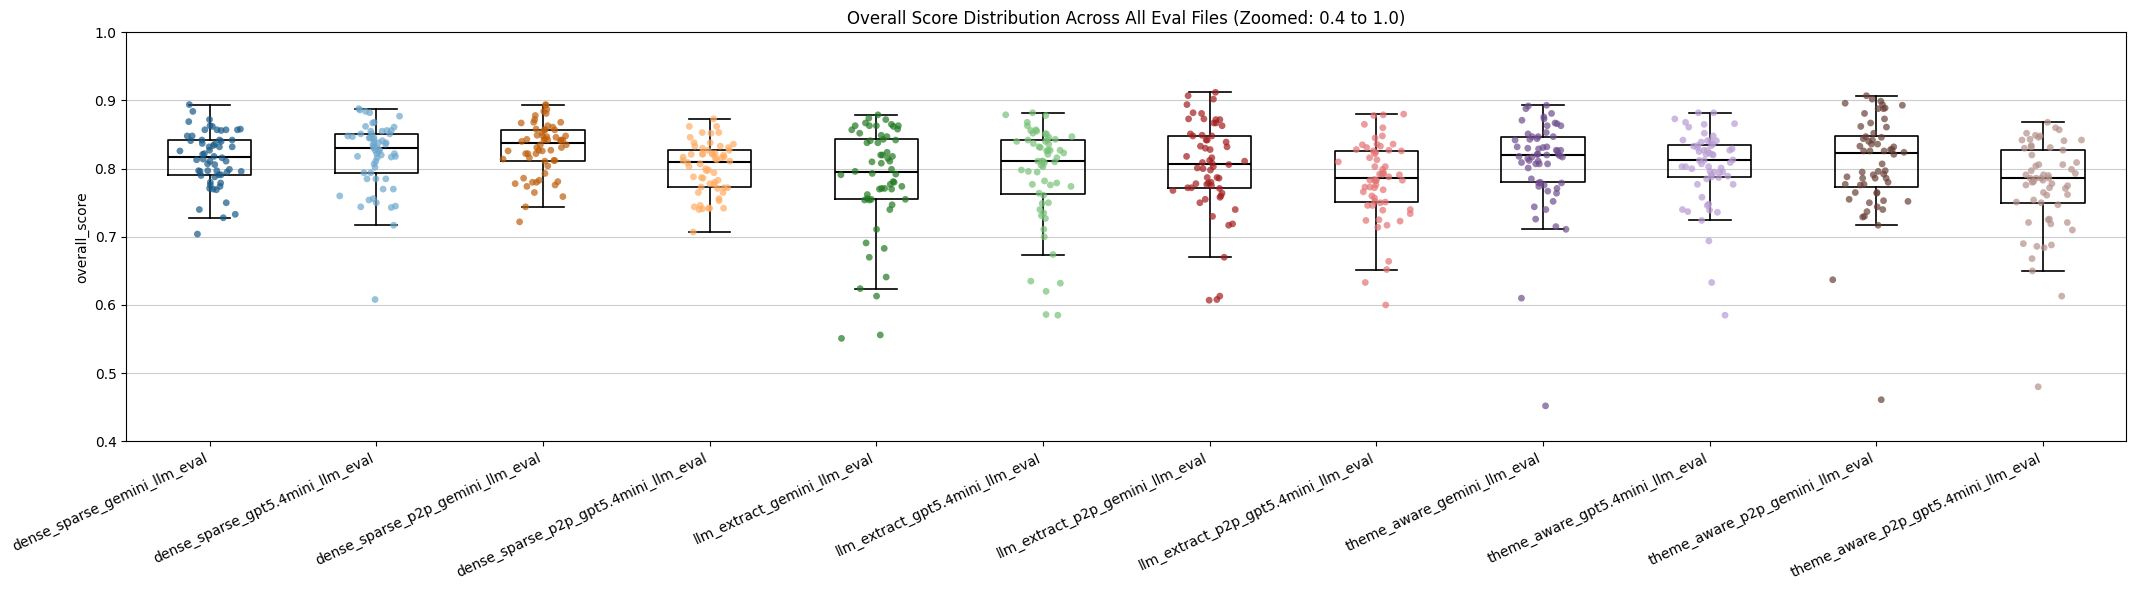

In [87]:
# Zoom-in view for all-files overall score distribution (y-axis: 0.4 to 1.0)
if "file_scores" not in globals() or not file_scores:
    file_scores = plot_all_files_overall_scores()

labels = list(file_scores.keys())
values = [file_scores[label] for label in labels]
group_color_map = _build_group_color_map(labels)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
positions = np.arange(1, len(labels) + 1)

box = ax.boxplot(
    values,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=False,
    zorder=1,
)
for line in box["boxes"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["whiskers"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["caps"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

for idx, (label, scores) in enumerate(zip(labels, values), start=1):
    if len(scores) == 0:
        continue
    jitter = np.random.normal(idx, 0.08, size=len(scores))
    point_color = _model_tinted_color(label, group_color_map)
    ax.scatter(
        jitter,
        scores,
        alpha=0.7,
        s=24,
        color=point_color,
        edgecolors="none",
        zorder=3,
    )

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
ax.set_ylabel("overall_score", color="black")
ax.set_title("Overall Score Distribution Across All Eval Files (Zoomed: 0.4 to 1.0)", color="black")
ax.set_ylim(0.4, 1.0)
ax.grid(True, axis="y", alpha=0.2, color="black")
ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

## Visualization w/o P2P

Loaded 6 files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse] gemini: n=60, mean=0.815
  [dense_sparse] gpt5.4mini: n=60, mean=0.819
  [llm_extract] gemini: n=60, mean=0.760
  [llm_extract] gpt5.4mini: n=60, mean=0.792
  [theme_aware] gemini: n=60, mean=0.808
  [theme_aware] gpt5.4mini: n=60, mean=0.803


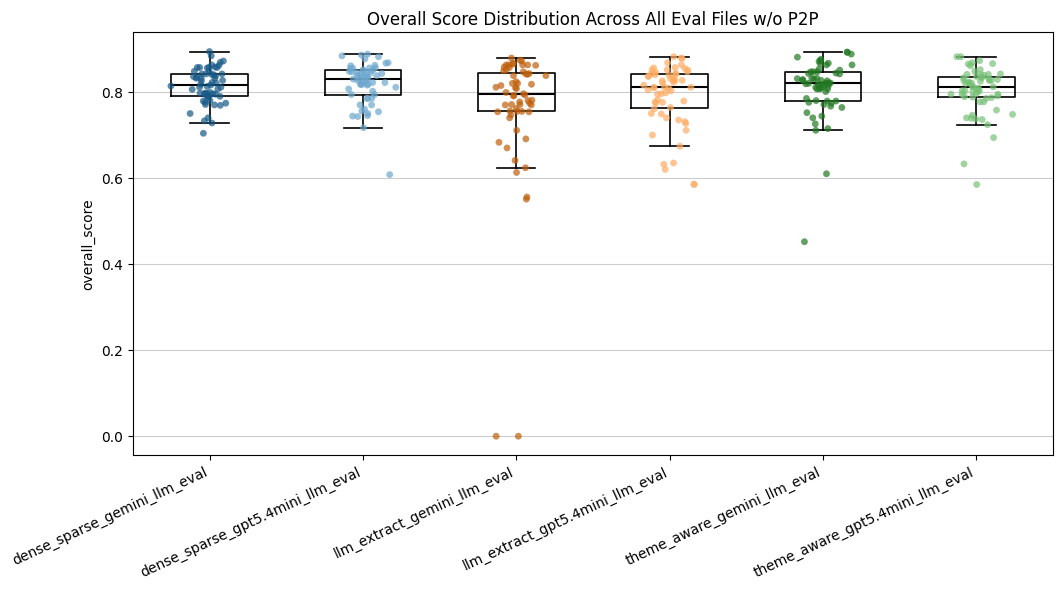

In [88]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors


def _resolve_eval_dir(target_dir: str | Path):
    target_dir = Path(target_dir)
    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / target_dir
        if candidate.exists():
            resolved = candidate
            break

    if resolved is None:
        raise FileNotFoundError(
            f"Cannot find {target_dir}. Current working directory: {Path.cwd()}"
        )

    return resolved


def _group_model_sort_key(stem: str):
    suffix = "_llm_eval"
    core = stem[:-len(suffix)] if stem.endswith(suffix) else stem

    # Match known model suffixes at the end so group names can contain any underscores.
    known_models = ["gemini", "gpt5.4mini"]
    for model_name in known_models:
        marker = f"_{model_name}"
        if core.endswith(marker):
            group_name = core[: -len(marker)]
            return group_name, model_name

    # Fallback for unexpected names: keep deterministic ordering.
    return core, ""


def _group_name_from_stem(stem: str):
    group_name, _ = _group_model_sort_key(stem)
    return group_name


def _build_group_color_map(stems):
    group_order = []
    for stem in stems:
        group_name = _group_name_from_stem(stem)
        if group_name not in group_order:
            group_order.append(group_name)

    cmap = plt.get_cmap("tab10")
    return {group: cmap(i % 10) for i, group in enumerate(group_order)}


def _blend_with_white(color, amount=0.35):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1.0 - rgb) * amount)


def _blend_with_black(color, amount=0.25):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb * (1.0 - amount))


def _model_tinted_color(label: str, group_color_map):
    group_name, model_name = _group_model_sort_key(label)
    base_color = group_color_map[group_name]

    model = str(model_name).lower()
    if model == "gemini":
        return _blend_with_black(base_color, amount=0.25)
    if "gpt" in model:
        return _blend_with_white(base_color, amount=0.35)
    return base_color


def plot_all_files_overall_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        [p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()],
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("Overall Score Distribution Across All Eval Files w/o P2P", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


file_scores = plot_all_files_overall_scores()

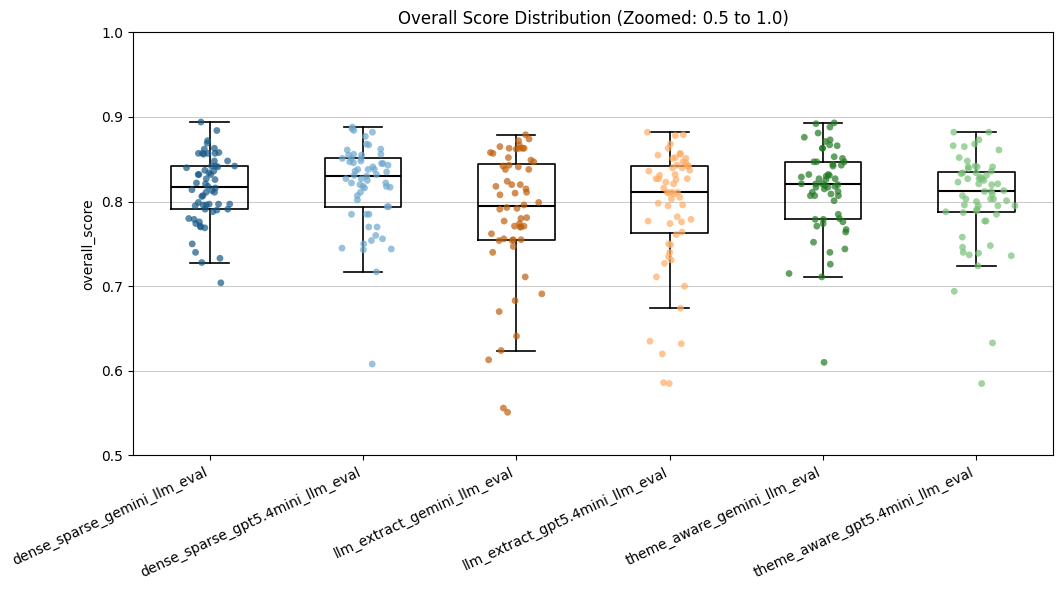

In [89]:
# Zoom-in view for overall score distribution (y-axis: 0.5 to 1.0)
if "file_scores" not in globals() or not file_scores:
    file_scores = plot_all_files_overall_scores()

labels = list(file_scores.keys())
values = [file_scores[label] for label in labels]
group_color_map = _build_group_color_map(labels)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
positions = np.arange(1, len(labels) + 1)

box = ax.boxplot(
    values,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=False,
    zorder=1,
)
for line in box["boxes"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["whiskers"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["caps"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

for idx, (label, scores) in enumerate(zip(labels, values), start=1):
    if len(scores) == 0:
        continue
    jitter = np.random.normal(idx, 0.08, size=len(scores))
    point_color = _model_tinted_color(label, group_color_map)
    ax.scatter(
        jitter,
        scores,
        alpha=0.7,
        s=24,
        color=point_color,
        edgecolors="none",
        zorder=3,
    )

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
ax.set_ylabel("overall_score", color="black")
ax.set_title("Overall Score Distribution (Zoomed: 0.5 to 1.0)", color="black")
ax.set_ylim(0.5, 1.0)
ax.grid(True, axis="y", alpha=0.2, color="black")
ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

## Visualization with P2P

Loaded 6 p2p files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse_p2p] gemini: n=60, mean=0.829
  [dense_sparse_p2p] gpt5.4mini: n=60, mean=0.801
  [llm_extract_p2p] gemini: n=60, mean=0.802
  [llm_extract_p2p] gpt5.4mini: n=60, mean=0.782
  [theme_aware_p2p] gemini: n=60, mean=0.807
  [theme_aware_p2p] gpt5.4mini: n=60, mean=0.774


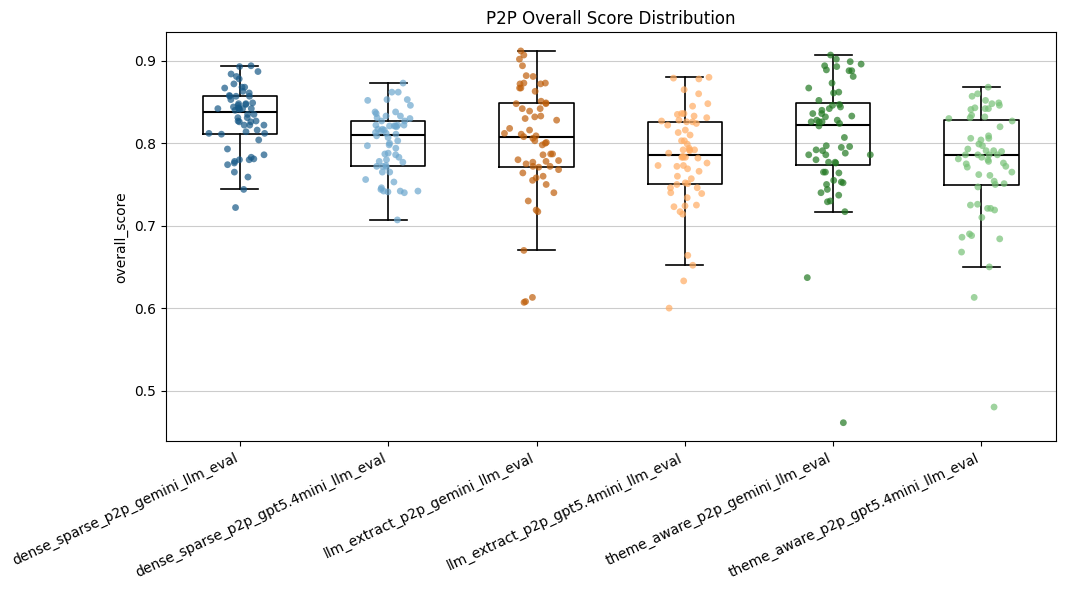

In [90]:
def plot_all_files_overall_scores_p2p(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        [p for p in resolved_dir.glob(pattern) if "p2p" in p.stem.lower()],
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(
            f"No p2p files matching {pattern} found in {resolved_dir}"
        )

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} p2p files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("P2P Overall Score Distribution", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


p2p_file_scores = plot_all_files_overall_scores_p2p()

## Visualization (Gemini)

In [91]:
def plot_all_files_overall_scores_models(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    model = "gemini",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        [p for p in resolved_dir.glob(pattern) if model in p.stem.lower()],
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(
            f"No {model} files matching {pattern} found in {resolved_dir}"
        )

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]
    group_color_map = _build_group_color_map(labels)

    print(f"Loaded {len(labels)} {model} files from: {resolved_dir}")
    for label, scores in file_scores.items():
        group_name, model_name = _group_model_sort_key(label)
        print(
            f"  [{group_name}] {model_name}: n={len(scores)}, mean={scores.mean():.3f}"
            if len(scores)
            else f"  [{group_name}] {model_name}: n=0"
        )

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, (label, scores) in enumerate(zip(labels, values), start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        point_color = _model_tinted_color(label, group_color_map)
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=point_color,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title(f"{model.capitalize()} Overall Score Distribution", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores

Loaded 6 gemini files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse] gemini: n=60, mean=0.815
  [dense_sparse_p2p] gemini: n=60, mean=0.829
  [llm_extract] gemini: n=60, mean=0.760
  [llm_extract_p2p] gemini: n=60, mean=0.802
  [theme_aware] gemini: n=60, mean=0.808
  [theme_aware_p2p] gemini: n=60, mean=0.807


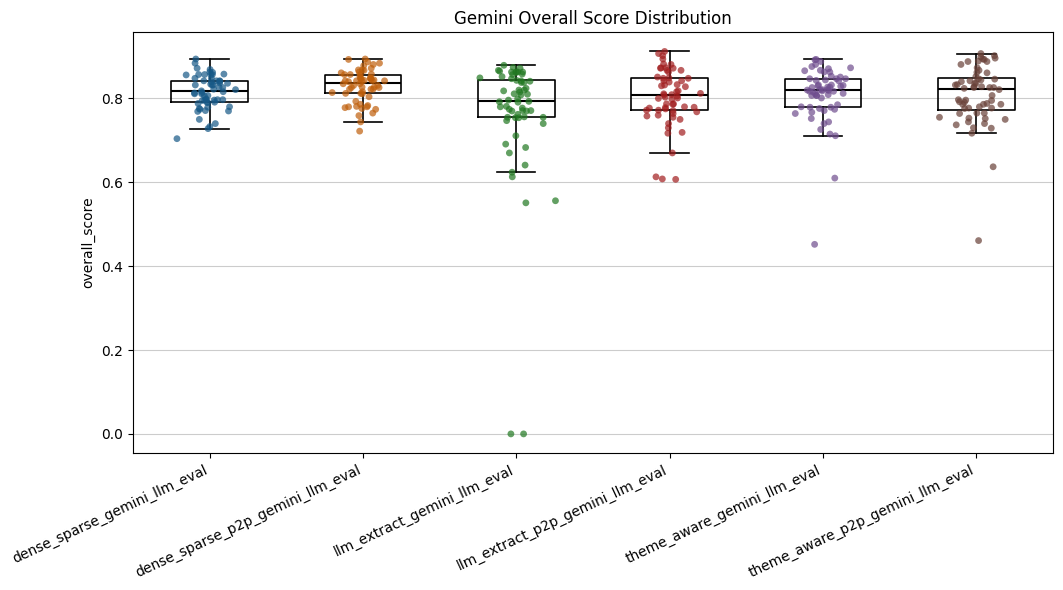

In [92]:
gemini_file_scores = plot_all_files_overall_scores_models(model="gemini")

### Zoomed Graph

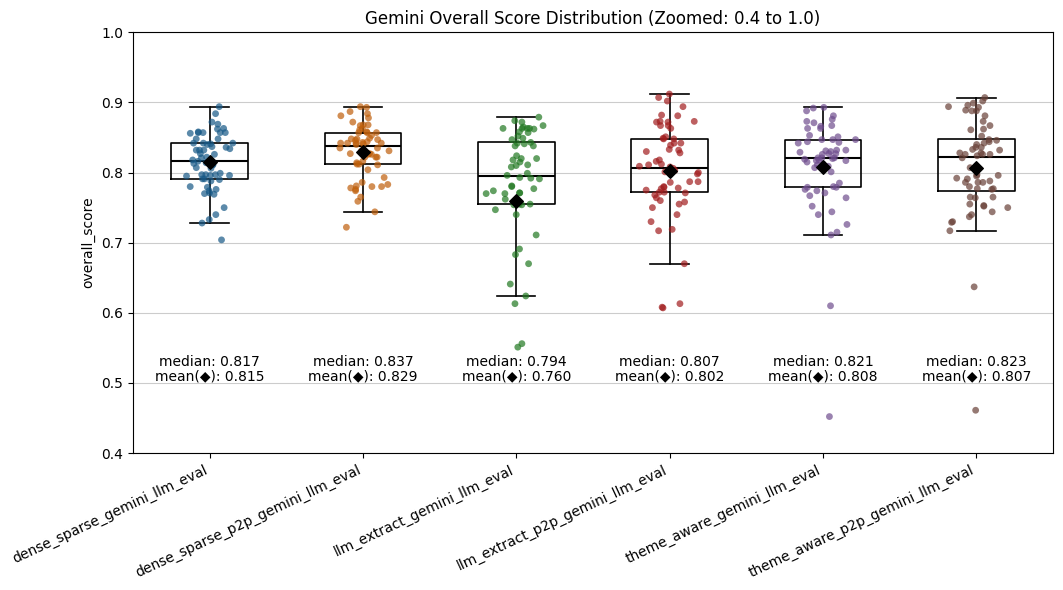

In [93]:
# Zoom-in view for Gemini overall score distribution (y-axis: 0.4 to 1.0)
if "gemini_file_scores" not in globals() or not gemini_file_scores:
    gemini_file_scores = plot_all_files_overall_scores_gemini()

labels = list(gemini_file_scores.keys())
values = [gemini_file_scores[label] for label in labels]
group_color_map = _build_group_color_map(labels)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
positions = np.arange(1, len(labels) + 1)

box = ax.boxplot(
    values,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=False,
    zorder=1,
)
for line in box["boxes"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["whiskers"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["caps"]:
    line.set_color("black")
    line.set_linewidth(1.2)
for line in box["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

for idx, (label, scores) in enumerate(zip(labels, values), start=1):
    if len(scores) == 0:
        continue
    jitter = np.random.normal(idx, 0.08, size=len(scores))
    point_color = _model_tinted_color(label, group_color_map)
    mean_value = float(np.mean(scores))
    median_value = float(np.median(scores))
    ax.scatter(
        jitter,
        scores,
        alpha=0.7,
        s=24,
        color=point_color,
        edgecolors="none",
        zorder=3,
    )
    ax.scatter(
        [idx],
        [mean_value],
        color="black",
        s=48,
        marker="D",
        zorder=4,
    )
    ax.text(
        idx,
        0.5,
        f"mean(◆): {mean_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "none",
            "pad": 0.2,
        },
        zorder=5,
    )
    ax.text(
        idx,
        0.52,
        f"median: {median_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "none",
            "pad": 0.2,
        },
        zorder=5,
    )

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
ax.set_ylabel("overall_score", color="black")
ax.set_title("Gemini Overall Score Distribution (Zoomed: 0.4 to 1.0)", color="black")
ax.set_ylim(0.4, 1.0)
ax.grid(True, axis="y", alpha=0.2, color="black")
ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

## Visualization (GPT)

Loaded 6 gpt files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  [dense_sparse] gpt5.4mini: n=60, mean=0.819
  [dense_sparse_p2p] gpt5.4mini: n=60, mean=0.801
  [llm_extract] gpt5.4mini: n=60, mean=0.792
  [llm_extract_p2p] gpt5.4mini: n=60, mean=0.782
  [theme_aware] gpt5.4mini: n=60, mean=0.803
  [theme_aware_p2p] gpt5.4mini: n=60, mean=0.774


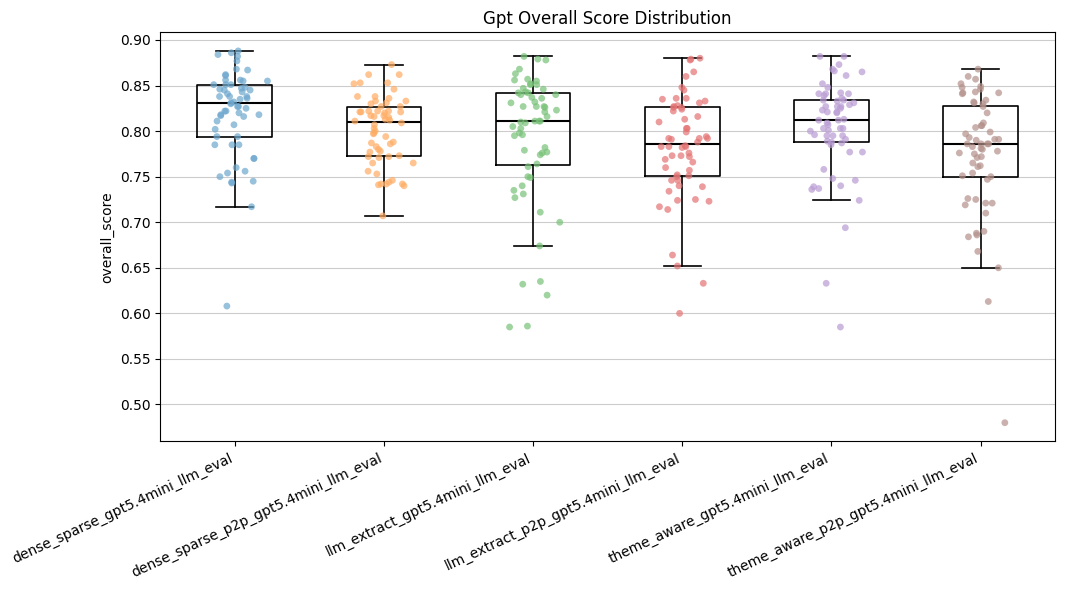

In [94]:
gemini_file_scores = plot_all_files_overall_scores_models(model="gpt")

## Question Visualization

Loaded 12 files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
Excluded test IDs: []
Queries per file: 12
Runs per query: 5
Complexity by query:
  Q1: high
  Q2: high
  Q3: medium
  Q4: medium
  Q5: medium
  Q6: medium
  Q7: medium
  Q8: low
  Q9: low
  Q10: low
  Q11: low
  Q12: low


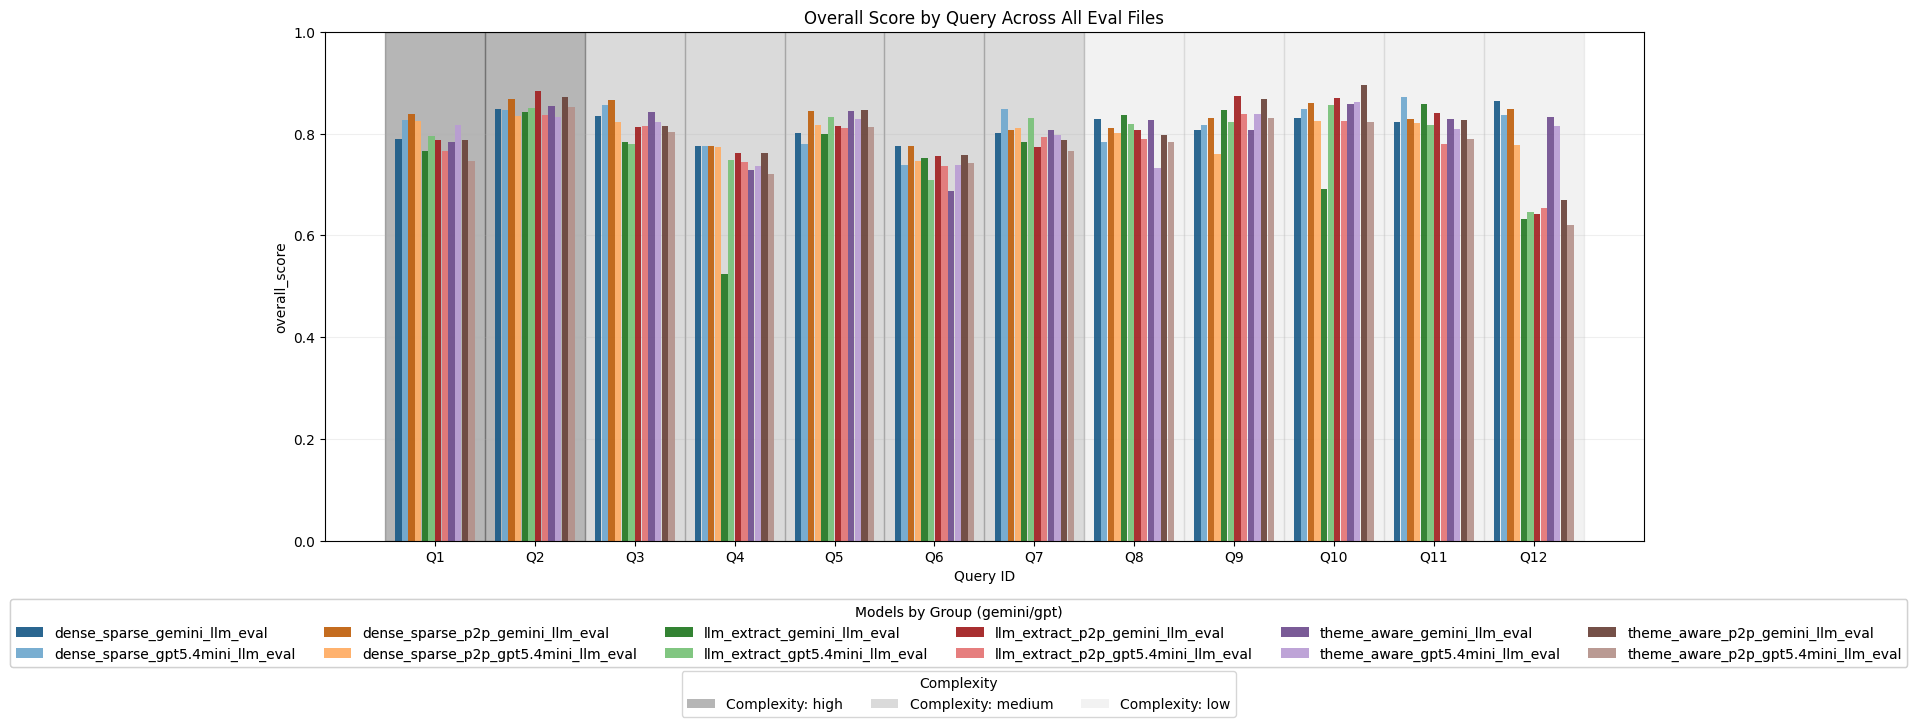

In [95]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors
from matplotlib.patches import Patch


QUERY_COMPLEXITY = {
    1: "high",
    2: "high",
    3: "medium",
    4: "medium",
    5: "medium",
    6: "medium",
    7: "medium",
    8: "low",
    9: "low",
    10: "low",
    11: "low",
    12: "low",
}

COMPLEXITY_BAND_COLOR = "#4a4a4a"
COMPLEXITY_BAND_ALPHA = {
    "high": 0.4,
    "medium": 0.2,
    "low": 0.07,
    "unknown": 0.04,
}


def _filter_results_by_test_id(results: dict):
    return {k: v for k, v in results.items() if k not in EXCLUDED_TEST_IDS}


def _resolve_eval_dir(target_dir: str | Path):
    target_dir = Path(target_dir)
    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / target_dir
        if candidate.exists():
            resolved = candidate
            break

    if resolved is None:
        raise FileNotFoundError(
            f"Cannot find {target_dir}. Current working directory: {Path.cwd()}"
        )

    return resolved


def _group_model_sort_key(stem: str):
    suffix = "_llm_eval"
    core = stem[:-len(suffix)] if stem.endswith(suffix) else stem

    known_models = ["gemini", "gpt5.4mini"]
    for model_name in known_models:
        marker = f"_{model_name}"
        if core.endswith(marker):
            group_name = core[: -len(marker)]
            return group_name, model_name

    return core, ""


def _group_name_from_stem(stem: str):
    group_name, _ = _group_model_sort_key(stem)
    return group_name


def _build_group_color_map(stems):
    group_order = []
    for stem in stems:
        group_name = _group_name_from_stem(stem)
        if group_name not in group_order:
            group_order.append(group_name)

    cmap = plt.get_cmap("tab10")
    return {group: cmap(i % 10) for i, group in enumerate(group_order)}


def _blend_with_white(color, amount=0.35):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1.0 - rgb) * amount)


def _blend_with_black(color, amount=0.25):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb * (1.0 - amount))


def _model_tinted_color(label: str, group_color_map):
    group_name, model_name = _group_model_sort_key(label)
    base_color = group_color_map[group_name]

    model = str(model_name).lower()
    if model == "gemini":
        return _blend_with_black(base_color, amount=0.25)
    if "gpt" in model:
        return _blend_with_white(base_color, amount=0.35)
    return base_color


def _extract_test_num(test_id: str):
    return int(str(test_id).split("_")[-1])


def _query_ids_from_sorted_keys(sorted_keys, runs_per_query: int):
    test_nums = [_extract_test_num(k) for k in sorted_keys]
    usable_len = (len(test_nums) // runs_per_query) * runs_per_query
    if usable_len == 0:
        return []
    grouped_nums = np.asarray(test_nums[:usable_len], dtype=int).reshape(-1, runs_per_query)
    return (((grouped_nums[:, 0] - 1) // runs_per_query) + 1).astype(int).tolist()


def _complexity_for_query_id(query_id: int):
    return QUERY_COMPLEXITY.get(int(query_id), "unknown")


def _complexity_legend_handles():
    return [
        Patch(facecolor=COMPLEXITY_BAND_COLOR, alpha=COMPLEXITY_BAND_ALPHA["high"], edgecolor="none", label="Complexity: high"),
        Patch(facecolor=COMPLEXITY_BAND_COLOR, alpha=COMPLEXITY_BAND_ALPHA["medium"], edgecolor="none", label="Complexity: medium"),
        Patch(facecolor=COMPLEXITY_BAND_COLOR, alpha=COMPLEXITY_BAND_ALPHA["low"], edgecolor="none", label="Complexity: low"),
    ]


def plot_overall_scores_by_query(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    runs_per_query: int = 5,
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(
        list(resolved_dir.glob(pattern)),
        key=lambda p: (*_group_model_sort_key(p.stem), p.stem),
    )

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_names = []
    file_series = []
    file_query_ids = []
    query_count = None

    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        filtered_results = _filter_results_by_test_id(data.get("results", {}))
        sorted_keys = sorted(filtered_results.keys(), key=lambda x: int(x.split("_")[-1]))
        query_ids = _query_ids_from_sorted_keys(sorted_keys, runs_per_query)
        scores = np.array(
            [filtered_results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        )
        scores = scores[~np.isnan(scores)]
        usable = scores[: (len(scores) // runs_per_query) * runs_per_query]
        if usable.size == 0:
            continue

        grouped = usable.reshape(-1, runs_per_query)
        query_means = grouped.mean(axis=1)

        if query_count is None:
            query_count = len(query_means)
        else:
            query_count = min(query_count, len(query_means))

        file_names.append(file_path.stem)
        file_series.append(query_means)
        file_query_ids.append(query_ids)

    if query_count is None or query_count == 0:
        raise ValueError("No overall_score values found in the selected files")

    query_count = int(query_count)
    file_series = [means[:query_count] for means in file_series]
    shared_query_ids = file_query_ids[0][:query_count] if file_query_ids else list(range(1, query_count + 1))
    query_labels = [f"Q{qid}" for qid in shared_query_ids]
    group_color_map = _build_group_color_map(file_names)

    print(f"Loaded {len(file_series)} files from: {resolved_dir}")
    print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
    print(f"Queries per file: {query_count}")
    print(f"Runs per query: {runs_per_query}")
    print("Complexity by query:")
    for qid in shared_query_ids:
        print(f"  Q{qid}: {_complexity_for_query_id(qid)}")

    fig, ax = plt.subplots(figsize=(max(14, query_count * 1.1), 6.5))
    x = np.arange(query_count)
    n_files = len(file_names)
    group_width = 0.8
    bar_width = group_width / max(n_files, 1)
    offsets = (np.arange(n_files) - (n_files - 1) / 2) * bar_width

    for i, qid in enumerate(shared_query_ids):
        complexity = _complexity_for_query_id(qid)
        band_alpha = COMPLEXITY_BAND_ALPHA.get(complexity, COMPLEXITY_BAND_ALPHA["unknown"])
        ax.axvspan(i - 0.5, i + 0.5, color=COMPLEXITY_BAND_COLOR, alpha=band_alpha, zorder=0)

    for file_idx, (file_name, means) in enumerate(zip(file_names, file_series)):
        positions = x + offsets[file_idx]
        bar_color = _model_tinted_color(file_name, group_color_map)
        ax.bar(
            positions,
            means,
            width=bar_width * 0.95,
            alpha=0.9,
            color=bar_color,
            label=file_name,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(query_labels)
    ax.set_xlabel("Query ID")
    ax.set_ylabel("overall_score")
    ax.set_title("Overall Score by Query Across All Eval Files")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.2)

    file_handles, file_labels = ax.get_legend_handles_labels()
    label_to_handle = {label: handle for handle, label in zip(file_handles, file_labels)}

    group_to_models = {}
    for label in file_labels:
        group_name, model_name = _group_model_sort_key(label)
        group_to_models.setdefault(group_name, {})[model_name] = label

    group_order = []
    for label in file_labels:
        group_name, _ = _group_model_sort_key(label)
        if group_name not in group_order:
            group_order.append(group_name)

    model_order = ["gemini", "gpt5.4mini"]
    paired_model_labels = []
    for group_name in group_order:
        for model in model_order:
            label = group_to_models.get(group_name, {}).get(model)
            if label:
                paired_model_labels.append(label)
    paired_model_handles = [label_to_handle[label] for label in paired_model_labels]

    complexity_handles = _complexity_legend_handles()
    complexity_labels = [h.get_label() for h in complexity_handles]

    model_legend = fig.legend(
        paired_model_handles,
        paired_model_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.08),
        ncol=max(len(group_order), 1),
        frameon=True,
        title="Models by Group (gemini/gpt)",
    )
    fig.add_artist(model_legend)

    fig.legend(
        complexity_handles,
        complexity_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=3,
        frameon=True,
        title="Complexity",
    )

    plt.tight_layout(rect=(0, 0.07, 1, 1))
    plt.show()

    return file_names, file_series


file_names, file_series = plot_overall_scores_by_query()


# Function to plot results for each model

In [96]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _filter_results_by_test_id(results: dict):
    return {k: v for k, v in results.items() if k not in EXCLUDED_TEST_IDS}


def _resolve_eval_json(target_rel: str | Path):
    target_rel = Path(target_rel)

    # Support both full relative paths and bare filenames.
    search_candidates = [target_rel]
    if not target_rel.is_absolute() and target_rel.parent == Path("."):
        search_candidates.extend(
            [
                Path("data/llm_eval_results_compare/comparison_llm_eval_results") / target_rel,
                Path("data/comparison_llm_eval_results") / target_rel,
            ]
        )

    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in search_candidates:
            candidate = base / rel
            if candidate.exists():
                resolved = candidate
                break
        if resolved is not None:
            break

    if resolved is None:
        attempted = ", ".join(str(p) for p in search_candidates)
        raise FileNotFoundError(
            f"Cannot find any of [{attempted}]. Current working directory: {Path.cwd()}"
        )

    with resolved.open("r", encoding="utf-8") as f:
        return resolved, json.load(f)


def plot_eval_results(
    target_rel: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results/self_generated_test_cases_eval.json",
    runs_per_query: int = 5,
):
    resolved, data = _resolve_eval_json(target_rel)

    results = _filter_results_by_test_id(data["results"])
    sorted_keys = sorted(results.keys(), key=lambda x: int(x.split("_")[-1]))

    metric_series = {
        "policy_faithfulness": np.array(
            [results[k].get("policy", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_answer_relevance": np.array(
            [results[k].get("policy", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_correctness": np.array(
            [results[k].get("policy", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_faithfulness": np.array(
            [results[k].get("provider", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_answer_relevance": np.array(
            [results[k].get("provider", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_correctness": np.array(
            [results[k].get("provider", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "query_alignment": np.array(
            [results[k].get("query_alignment", {}).get("comparison_query_relevance", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "correctness": np.array(
            [results[k].get("compare_quality", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_sim": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_sim", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_diff": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_diff", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "completeness": np.array(
            [results[k].get("compare_quality", {}).get("completeness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "balance": np.array(
            [results[k].get("compare_quality", {}).get("balance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "comparison_overall_score": np.array(
            [results[k].get("comparison_overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "overall_score": np.array(
            [results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
    }

    plot_metrics = [
        "policy_faithfulness",
        "policy_answer_relevance",
        "policy_correctness",
        "provider_faithfulness",
        "provider_answer_relevance",
        "provider_correctness",
        "query_alignment",
        "correctness",
        "accuracy_sim",
        "accuracy_diff",
        "completeness",
        "balance",
        "comparison_overall_score",
        "overall_score",
    ]

    print(f"Loaded from: {resolved}")
    print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
    print(f"Total cases after filter: {len(sorted_keys)}")
    print(f"Runs per query: {runs_per_query}")

    fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(9, 4 * len(plot_metrics)), sharex=False)
    if len(plot_metrics) == 1:
        axes = [axes]

    for ax, metric_name in zip(axes, plot_metrics):
        values = np.asarray(metric_series[metric_name], dtype=float)
        usable = values[: (len(values) // runs_per_query) * runs_per_query]
        grouped = usable.reshape(-1, runs_per_query)

        means = grouped.mean(axis=1)
        stds = grouped.std(axis=1)
        x = np.arange(len(means))

        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='black', label='Mean ± Std', zorder=3)

        for i in range(grouped.shape[0]):
            jitter = np.random.normal(i, 0.05, size=grouped.shape[1])
            if i == 0:
                ax.scatter(jitter, grouped[i], alpha=0.6, label='Individual Runs', zorder=2)
            else:
                ax.scatter(jitter, grouped[i], alpha=0.6, zorder=2)

        ax.set_xlabel("Query ID")
        ax.set_ylabel("Score")
        ax.set_title(f"{metric_name} Stability and Distribution Across {runs_per_query} Runs")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{i+1}" for i in range(len(means))])
        ax.legend()
        ax.grid(True, axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()
    return resolved, metric_series


# Convert to Readable (CSV)

## Score Only

In [97]:
import csv


def export_flat_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted([p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()])

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        filtered_results = _filter_results_by_test_id(data["results"])
        sorted_keys = sorted(filtered_results.keys(), key=lambda x: int(x.split("_")[-1]))

        rows = []
        for test_id in sorted_keys:
            record = filtered_results[test_id]
            policy = record.get("policy", {})
            provider = record.get("provider", {})
            query_alignment = record.get("query_alignment", {})
            compare_quality = record.get("compare_quality", {})

            row = {
                "test_id": test_id,
                "query": record.get("query", ""),
                "answer": record.get("answer", ""),
                "policy_faithfulness": policy.get("faithfulness", {}).get("score", ""),
                "policy_answer_relevance": policy.get("answer_relevance", {}).get("score", ""),
                "policy_correctness": policy.get("correctness", {}).get("score", ""),
                "provider_faithfulness": provider.get("faithfulness", {}).get("score", ""),
                "provider_answer_relevance": provider.get("answer_relevance", {}).get("score", ""),
                "provider_correctness": provider.get("correctness", {}).get("score", ""),
                "query_alignment": query_alignment.get("comparison_query_relevance", ""),
                "correctness": compare_quality.get("correctness", {}).get("score", ""),
                "accuracy_sim": compare_quality.get("accuracy_sim", {}).get("score", ""),
                "accuracy_diff": compare_quality.get("accuracy_diff", {}).get("score", ""),
                "completeness": compare_quality.get("completeness", {}).get("score", ""),
                "balance": compare_quality.get("balance", {}).get("score", ""),
                "comparison_overall_score": record.get("comparison_overall_score", ""),
                "overall_score": record.get("overall_score", ""),
            }
            rows.append(row)

        csv_path = file_path.with_name(file_path.stem + "_flat_scores.csv")
        fieldnames = list(rows[0].keys()) if rows else []

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")

    return exported


exported_csvs = export_flat_scores()


Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval_flat_scores.csv
Rows written: 60
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval_flat_scores.csv
Rows written: 60
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_gemini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eva

## Include Reasons

In [ ]:
""""
def _flatten_record(value, parent_key="", sep="."):
    flat = {}

    if isinstance(value, dict):
        for k, v in value.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
            flat.update(_flatten_record(v, new_key, sep=sep))
    elif isinstance(value, list):
        # Keep lists as JSON strings so variable-length arrays stay in one column.
        flat[parent_key] = json.dumps(value, ensure_ascii=False)
    else:
        flat[parent_key] = value

    return flat


def export_all_query_fields_to_csv(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted([p for p in resolved_dir.glob(pattern) if "p2p" not in p.stem.lower()])

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        results = _filter_results_by_test_id(data.get("results", {}))
        # Keep JSON insertion order; do not sort test ids.
        key_order = list(results.keys())

        rows = []
        ordered_columns = ["test_id"]

        for test_id in key_order:
            record = results.get(test_id, {})
            flat_record = _flatten_record(record)
            row = {"test_id": test_id, **flat_record}
            rows.append(row)

            for col in row.keys():
                if col not in ordered_columns:
                    ordered_columns.append(col)

        fieldnames = ordered_columns
        csv_path = file_path.with_name(file_path.stem + "_all_fields.csv")

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            for row in rows:
                writer.writerow({k: row.get(k, "") for k in fieldnames})

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Excluded test IDs: {sorted(EXCLUDED_TEST_IDS)}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")
        print(f"Columns written: {len(fieldnames)}")

    return exported


all_fields_csvs = export_all_query_fields_to_csv()
all_fields_csvs
"""

Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval_all_fields.csv
Rows written: 60
Columns written: 38
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval_all_fields.csv
Rows written: 60
Columns written: 38
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_gemini_llm_eval.json
Excluded test IDs: []
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_e

{'dense_sparse_gemini_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gemini_llm_eval_all_fields.csv'),
 'dense_sparse_gpt5.4mini_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_gpt5.4mini_llm_eval_all_fields.csv'),
 'llm_extract_gemini_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_gemini_llm_eval_all_fields.csv'),
 'llm_extract_gpt5.4mini_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_gpt5.4mini_llm_eval_all_fields.csv'),
 'theme_aware_gemini_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_gemini_llm_eval_all